### AI Travel Agent & Expense Planner(Purpose: Trip planning for any city worldwide with Realtime data.")


###### • Real-time weather information : Travily
###### • Top attractions and activities : Travily
###### • Hotel cost calculation (per day × total days) Get avg. daily price from web search Travily then calulate for whole vacation
###### • Currency conversion to user's native currency : Get conversion rate from travily then convert to native pricing.
###### • Complete itinerary generation : Use webserach to generate itinerary based on data collected.
###### • Total expense calculation: Calulate total expense by adding hotel stay, activity cost, food cost, traveling cost
###### • generate a summary of the entire output : use LLM to generate summary of the total data collected.

###### user_inputs Location, total vacation duration, native currency.
######    |
###### search attraction and activity
###### 1. search attracation
###### 2. search restaurant
###### 3. search activity
###### 4. search transportation
######     |
###### search weather forcasting
###### 1. get current weather
###### 2. get weather forcast
######     |
###### search hotel costs
###### 1. search hotel
###### 2. estimate the hotel cost
###### 3. budget_range
######     |
###### calculate total cost
###### 1. add
###### 2. multiply
###### 3. calculated total cost
###### 4. calcualte the daily budget
######        | 
###### currency_converion
###### 1. get exchnage rate
###### 2. convert currency
######       | 
###### Itinery generation
###### 1. get day plan
###### 2. create full itinery
######     |
###### create Trip Summary
######       |
###### Retun complete travel plan

In [9]:
# Import Env Variables
from dotenv import load_dotenv
import os
load_dotenv(dotenv_path='C:\\Users\\sunny\\OneDrive\\Documents\\Agentic AI Course\\.env')

TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")
# print(TAVILY_API_KEY)

In [3]:
# Importing LLM
from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name="deepseek-r1-distill-llama-70b",
    temperature=0
)
response=llm.invoke("what is length of wall of china?")

In [4]:
# Custom Mathematical Tools
from langchain.tools import tool

@tool
def multiply(a: int, b: int) -> int:
    """
    Multiply two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The product of a and b.
    """
    return a * b

@tool
def add(a: int, b: int) -> int:
    """
    Add two integers.

    Args:
        a (int): The first integer.
        b (int): The second integer.

    Returns:
        int: The sum of a and b.
    """
    return a + b

@tool
def divide(a: int, b: int) -> float:
    """
    Divide two integers.

    Args:
        a (int): The numerator.
        b (int): The denominator (must not be 0).

    Returns:
        float: The result of division.
    """
    if b == 0:
        raise ValueError("Denominator cannot be zero.")
    return a / b

In [10]:
# creating the search tools
from langchain_community.tools.tavily_search import TavilySearchResults
search_tool=TavilySearchResults()

In [11]:
# creating weather tool
@tool
def weather_tool(location: str, duration: str) -> str:
    """
    Takes a location and duration, searches web for realtime weather forecast for the given location for given duration.

    Args:
        location (str): The location.
        duration (str): The duration.

    Returns:
        str: The weather forcast at location for given duration.
    """
    result = search_tool.invoke({"query":f"What is the real time weather forecast at {location} for the next {duration} days?"})
    return result[0].get('content')

In [29]:
# creating top attraction tool
@tool
def attractions_tool(location: str, native_currency: str) -> str:
    """
    Takes a location, native currency and searches web for top 5 attractions and activities in that location.

    Args:
        location (str): The location.
        native_currency: The native currency of user.

    Returns:
        str: The top 5 attractions and activities at location with their total cost in native currency.
    """
    result = search_tool.invoke({"query":f"What are the top 5 tourist attractions and activities at {location}, also provide the total price for activity or attraction in {native_currency}?"})
    return result[0].get('content')

In [13]:
# creating hotel tool
@tool
def hotel_tool(location: str, duration: str, native_cur:str) -> str:
    """
    Takes a location, duration and native currency, searches web for total price of the hotels at the given location for given duration.

    Args:
        location (str): The location.
        duration (str): The duration.
        native_cur (str): The user native currency.

    Returns:
        str: The total price at location for given duration in native currency.
    """
    result = search_tool.invoke({"query":f"What is the average hotel spend in {native_cur} at {location} If I stay for the next {duration} days?"})
    return result[0].get('content')

In [30]:
# creating itinerary tool
@tool
def itinerary_tool(location: str, native_cur:str, attractions_activities:str) -> str:
    """
    Takes a location, duration and native currency, searches web for total price of the hotels at the given location for given duration.

    Args:
        location (str): The location.
        native_cur (str): The user native currency.
        attractions_activities (str): The attractions and activities in that location.

    Returns:
        str: The complete itinerary of that location with attractions and activities involved.
    """
    result = search_tool.invoke({"query":f"Complete itinerary to visit following attractions or activities {attractions_activities} at {location} in my native currency {native_cur}?"})
    return result[0].get('content')

In [ ]:
# # creating total expense tool
# @tool
# def total_tool(hotel_expense: str, duration: str, native_cur:str, activities_cost:str) -> str:
#     """
#     Takes a hotel expense, duration, native currency and activities cost, calculates total expense at the given location for given duration.

#     Args:
#         hotel_expense (str): The total hotel expense.
#         duration (str): The duration.
#         native_cur (str): The user native currency.
#         activities_cost (str): Total cost for activities.

#     Returns:
#         str: The total cost at location for given duration in native currency.
#     """
#     result = search_tool.invoke({"query":f"{hotel_expense} + {activities_cost}"})
#     return result[0].get('content')

In [31]:
tools = [add, multiply, divide, weather_tool,attractions_tool,hotel_tool, itinerary_tool]

In [32]:
llm_with_tools=llm.bind_tools(tools)

In [16]:
response=llm_with_tools.invoke("Please suggest travel plan for Italy for 3 days, my native currency is INR")

In [17]:
response.content

''

In [18]:
response.tool_calls

[{'name': 'attractions_tool',
  'args': {'location': 'Italy'},
  'id': 'e0gbq1bp1',
  'type': 'tool_call'}]

In [33]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

In [38]:
SYSTEM_PROMPT = SystemMessage(
    content="You are a helpful assistant tasked with using add, multiply, divide, weather_tool,attractions_tool,hotel_tool and itinerary_tool for a user input of location, duration and native currency."
)
def function_1(state:MessagesState):
    
    user_question=state["messages"]
    
    input_question = [SYSTEM_PROMPT]+user_question
    
    response = llm_with_tools.invoke(input_question)
    
    return {
        "messages":[response]
    }

In [39]:
workflow = StateGraph(MessagesState)
workflow.add_node("llm_decision_step", function_1)
workflow.add_node("tools", ToolNode(tools))
workflow.add_edge(START, "llm_decision_step")
workflow.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)
workflow.add_edge("tools", "llm_decision_step")
react_graph2 = workflow.compile()

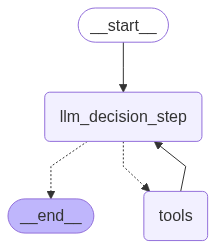

In [40]:
display(Image(react_graph2.get_graph(xray=True).draw_mermaid_png()))

In [41]:
messages = [HumanMessage(content="Please suggest travel plan for Italy for 3 days, my native currency is INR. Calculate the total cost, average daily cost, generate itinerary and summarize the complete information.")]
messages = react_graph2.invoke({"messages": messages})

In [42]:
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Please suggest travel plan for Italy for 3 days, my native currency is INR. Calculate the total cost, average daily cost, generate itinerary and summarize the complete information.
================================== Ai Message ==================================
Tool Calls:
  weather_tool (b43tby1gs)
 Call ID: b43tby1gs
  Args:
    duration: 3 days
    location: Italy
================================= Tool Message =================================
Name: weather_tool

| [27 Jun.](https://www.easeweather.com/europe/italy/day#date=2025-06-27 "The weather in Italy on the 27th of June") | Sunny Sunny | 37° /22° | 0 mm | 2.4 |  |
| [28 Jun.](https://www.easeweather.com/europe/italy/day#date=2025-06-28 "The weather in Italy on the 28th of June") | Sunny Sunny | 37° /24° | 0 mm | 2.7 |  |
| [29 Jun.](https://www.easeweather.com/europe/italy/day#date=2025-06-29 "The weather in Italy on the 29th of June") | Sunny Su